# AWS Athena & Glue IaC: Performance and Cost Optimization

## Guiding Question
> **How can we design and optimize a serverless data warehousing architecture on AWS that balances ingestion scalability, ease of cataloging, and SQL query cost efficiency?**

## Aim of the Story
This analysis walks through the provisioning and performance evaluation of an AWS serverless data warehousing stack using S3, Glue, and Athena. We investigate how partitioning large datasets affects query execution performance and AWS query billing costs, establishing a clear framework for optimizing serverless querying.

## Theoretical Framework & Mathematical Foundations

### 1. Serverless Billing Mechanics
Amazon Athena utilizes a serverless execution model where users are billed directly based on the **amount of data scanned** during query execution. The query execution cost $C$ (in USD) is formulated as:

$$C = D_{\text{scan}} \times \$5.00$$

Where:
- $D_{\text{scan}}$ is the total data scanned by the query engine (in Terabytes, TB).
- $\$5.00$ is the standard billing rate per TB scanned (as of current AWS Athena pricing).
- Athena enforces a minimum scan charge of **10 Megabytes (MB)** per query.

### 2. Partition Pruning
By organizing our data lake directory in S3 with hierarchical folder structures (such as `s3://bucket/data/year=YYYY/month=MM/`), we can register `year` and `month` as **partition keys** in our Glue Catalog.

When Athena runs a query, it compiles the execution plan and prunes folders that do not match the filter criteria. 

Let $F = \{F_1, F_2, \dots, F_N\}$ represent the complete set of data files. If we query the table without partition keys:

$$D_{\text{scan}} = \sum_{i=1}^{N_{\text{total}}} \text{Size}(F_i)$$

If we apply partition filters matching a subset of matching files $M \subset F$:

$$D_{\text{scan}} = \sum_{i \in M} \text{Size}(F_i)$$

Since $|M| \ll |F|$, partition pruning results in an order-of-magnitude reduction in data scanned, leading directly to linear cost savings.

## System Architecture

The diagram below outlines the flow of data and services in this serverless querying stack:

```mermaid
graph TD
    %% Provisioning Flows
    CFN_Template[CloudFormation Template] -->|Provisions Bucket| S3_My[(My S3 Bucket)]
    CFN_Template -->|Provisions Catalog Database| Glue_Database[AWS Glue Database]
    CFN_Template -->|Provisions Crawler| Glue_Crawler[AWS Glue Crawler]
    CFN_Template -->|Provisions Manual Table| Glue_ManualTable[Glue Table: orders_manual]
    CFN_Template -->|Provisions Workgroup| Athena_WG[Athena WorkGroup]
    
    %% Ingestion and Cataloging Flows
    S3_Source[(Source S3 Bucket)] -->|aws s3 cp| S3_My
    S3_My -->|Scan Data| Glue_Crawler
    Glue_Crawler -->|Auto-Discover Table: parquet_results| Glue_Database
    Glue_ManualTable -->|Reference Schema| Glue_Database
    
    %% Querying & Analysis Flows
    Athena[AWS Athena Serverless SQL] -->|Queries via WorkGroup| Glue_Database
    Athena -->|Saves Results to CSV| S3_My
    Local_Python[Local Jupyter / Python] -->|Loads CSV results| Local_Data[(Local Data: data/)]
```

### Goal: Environment Initialization

Import the required libraries for our analytical pipeline (`pandas`, `matplotlib`, `seaborn`) and configure plot style parameters to ensure uniform, professional styling for all generated figures.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plots styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

### Goal: Loading Query Results

Load the CSV formatted query results generated by AWS Athena into Pandas DataFrames and cast the metric columns (`order_count`, `total_revenue`, `avg_order_value`) to numeric data types for quantitative analysis.

In [2]:
# Load CSV files
q1_path = os.path.join("..", "data", "results_query1.csv")
q2_path = os.path.join("..", "data", "results_query2.csv")

df_q1 = pd.read_csv(q1_path)
df_q2 = pd.read_csv(q2_path)

# Convert numeric columns
for df in [df_q1, df_q2]:
    df['order_count'] = pd.to_numeric(df['order_count'])
    df['total_revenue'] = pd.to_numeric(df['total_revenue'])
    df['avg_order_value'] = pd.to_numeric(df['avg_order_value'])

print(f"Query 1 dataset shape: {df_q1.shape} (All time)")
print(f"Query 2 dataset shape: {df_q2.shape} (January 2023 only)")

Query 1 dataset shape: (40, 5) (All time)
Query 2 dataset shape: (40, 5) (January 2023 only)


### Goal: Inspecting the Raw Data Structure

Display the first 10 rows from the Query 1 (whole-table) dataset to verify the columns, schema, and initial data formats.

In [3]:
df_q1.head(10)

,region,status,order_count,total_revenue,avg_order_value
0,us-west,DELIVERED,242426,4.289545e+08,1769.42
1,us-east,DELIVERED,232606,4.122974e+08,1772.51
2,eu-west,DELIVERED,189340,3.353817e+08,1771.32
3,eu-central,DELIVERED,126743,2.233600e+08,1762.31
4,ap-northeast,DELIVERED,104990,1.854762e+08,1766.61
5,ap-south,DELIVERED,84427,1.499223e+08,1775.76
6,us-west,SHIPPED,54710,9.734120e+07,1779.22
7,us-east,SHIPPED,52349,9.262801e+07,1769.43
8,eu-west,SHIPPED,43089,7.655268e+07,1776.62
9,sa-east,DELIVERED,41991,7.526684e+07,1792.45


### Interpretation: Initial Data Observations

The sample rows show that each record details a unique combination of `region`, `status`, `order_count`, `total_revenue`, and `avg_order_value`. 
- Total revenue values are in the hundreds of millions (e.g., `us-west` has `4.2895E8`), which we will need to scale to Millions of USD in our plots to improve scannability.
- The highest revenue segments are corresponding to the `DELIVERED` status, which is expected for completed business transactions.

### Goal: Visualizing Regional Revenue Distribution

Aggregate the total revenue for each region across all order statuses and construct a horizontal bar plot to analyze geographical sales distribution.

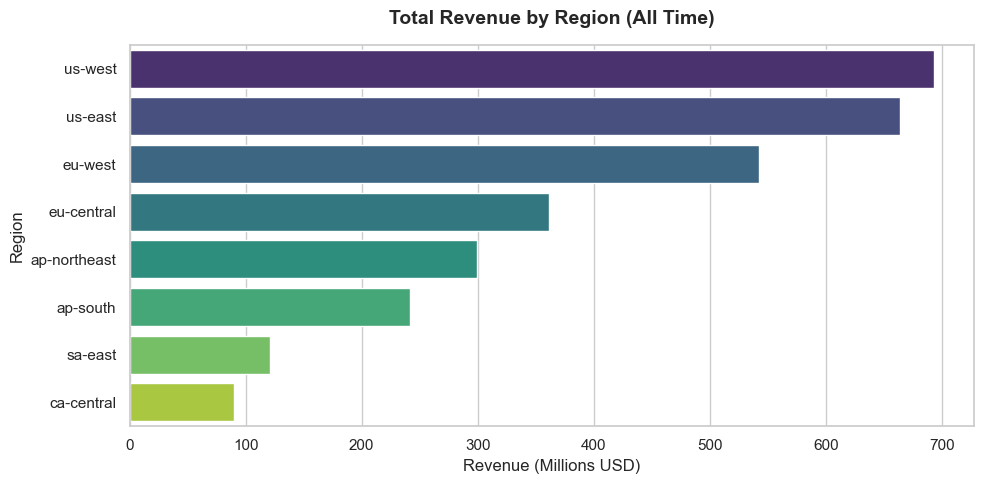

In [4]:
regional_revenue = df_q1.groupby('region')['total_revenue'].sum().sort_values(ascending=False).reset_index()
regional_revenue['total_revenue_millions'] = regional_revenue['total_revenue'] / 1e6

plt.figure(figsize=(10, 5))
sns.barplot(data=regional_revenue, x='total_revenue_millions', y='region', hue='region', legend=False, palette='viridis')
plt.title('Total Revenue by Region (All Time)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Revenue (Millions USD)', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

### Interpretation: Regional Sales Dominance

The regional breakdown reveals that `us-west` is our largest geographical market, producing over **$650 Million** in total revenue, followed by `us-east` at roughly **$620 Million** and `eu-west` at around **$500 Million**.
The smallest market is `ca-central` (Canada Central), which generates under **$100 Million** in historical sales. This distribution suggests that resource allocation and marketing focus should prioritize the dominant North American and Western European divisions.

### Goal: Analyzing Order Volume and Status Distribution

Create a grouped bar chart displaying order counts by region, categorized by fulfillment status, to detect regional operational anomalies or bottleneck patterns.

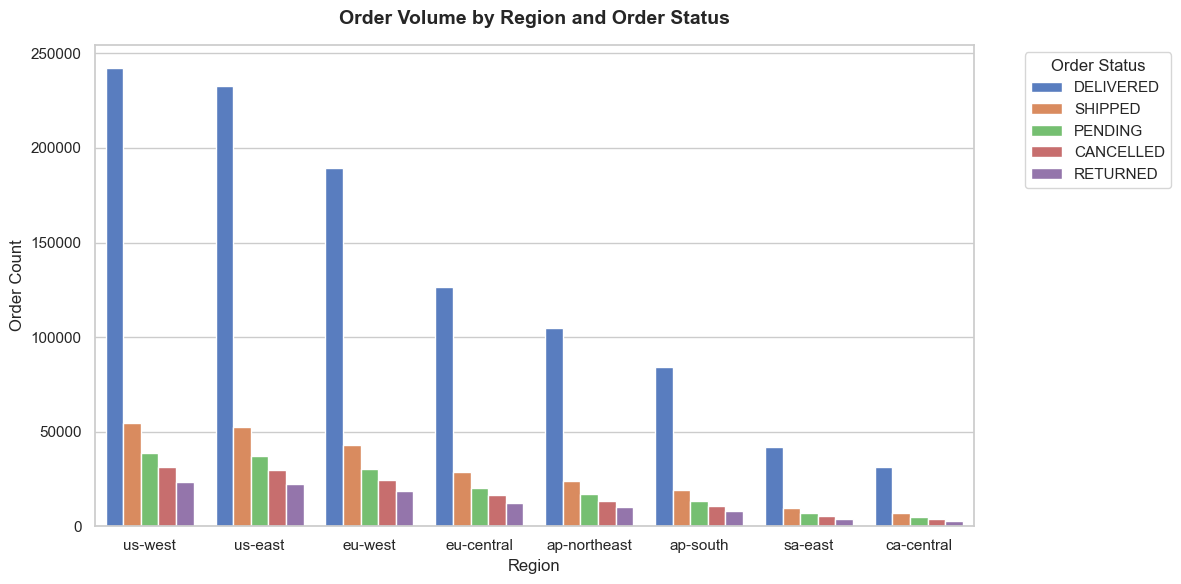

In [5]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_q1, x='region', y='order_count', hue='status', palette='muted')
plt.title('Order Volume by Region and Order Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.legend(title='Order Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Interpretation: Order Fulfillment Patterns

Across all regions, `DELIVERED` is the dominant status, indicating strong transaction fulfillment rates. 
- `SHIPPED` (active transit) and `PENDING` (processing queue) maintain proportional volumes relative to each region's size.
- The ratio of `CANCELLED` and `RETURNED` orders remains uniform across all regions. The lack of any spikes in returned or cancelled orders in specific regions indicates that shipping and localized product satisfaction remain highly consistent worldwide.

### Goal: Visualizing Monthly Segment Revenue

Plot the regional revenue distribution specifically for **January 2023** (Query 2 results) to examine if short-term monthly revenue distributions deviate from the long-term historical average.

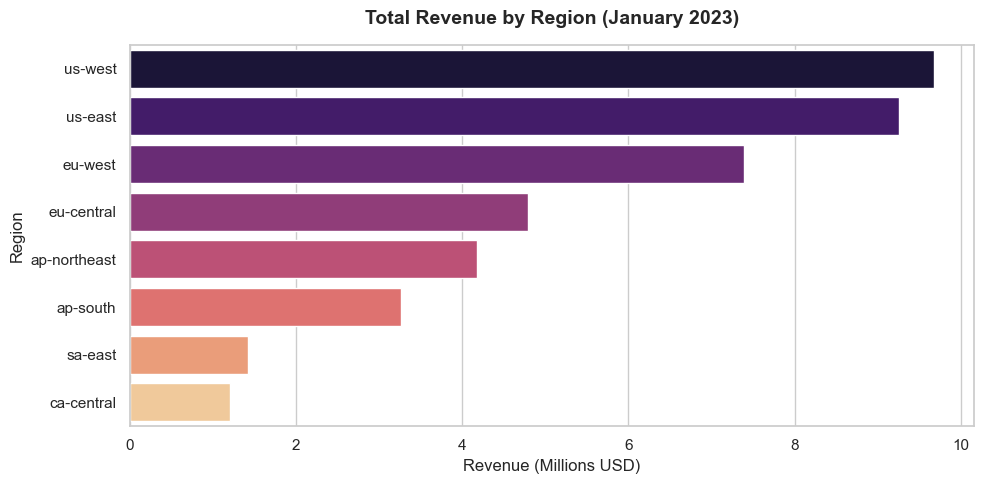

In [6]:
regional_revenue_jan23 = df_q2.groupby('region')['total_revenue'].sum().sort_values(ascending=False).reset_index()
regional_revenue_jan23['total_revenue_millions'] = regional_revenue_jan23['total_revenue'] / 1e6

plt.figure(figsize=(10, 5))
sns.barplot(data=regional_revenue_jan23, x='total_revenue_millions', y='region', hue='region', legend=False, palette='magma')
plt.title('Total Revenue by Region (January 2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Revenue (Millions USD)', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

### Interpretation: Monthly Distribution Consistency

The regional rankings in January 2023 exactly mirror the historical averages: `us-west` leads, followed by `us-east` and `eu-west`, while `ca-central` remains the smallest. This suggests that the distribution is stable and that seasonality or localized events did not introduce anomalies in regional contributions during early 2023.

### Goal: Loading Query Performance Metrics

Construct a Pandas DataFrame containing the metadata (data scanned in bytes, query queue times, and engine execution latencies) captured from the AWS Athena query logs to evaluate scanning efficiency.

In [7]:
# Setup stats from AWS Athena query execution results
metrics = {
    "QueryType": ["Whole Table (Unpartitioned)", "January 2023 (Partitioned)"],
    "DataScannedBytes": [7434568, 100414],  # bytes from query statistics
    "TotalExecutionTimeMs": [1436, 1000],
    "EngineExecutionTimeMs": [1240, 818]
}

df_metrics = pd.DataFrame(metrics)
df_metrics["DataScannedKB"] = df_metrics["DataScannedBytes"] / 1024
df_metrics["DataScannedMB"] = df_metrics["DataScannedBytes"] / (1024 * 1024)

df_metrics

,QueryType,DataScannedBytes,TotalExecutionTimeMs,EngineExecutionTimeMs,DataScannedKB,DataScannedMB
0,Whole Table (Unpartitioned),7434568,1436,1240,7260.320312,7.090157
1,January 2023 (Partitioned),100414,1000,818,98.060547,0.095762


### Goal: Comparing Query Latency and Data Scans

Generate side-by-side bar plots comparing the data scanned (in KB) and the Athena engine execution times (in milliseconds) between the unpartitioned and partitioned executions.

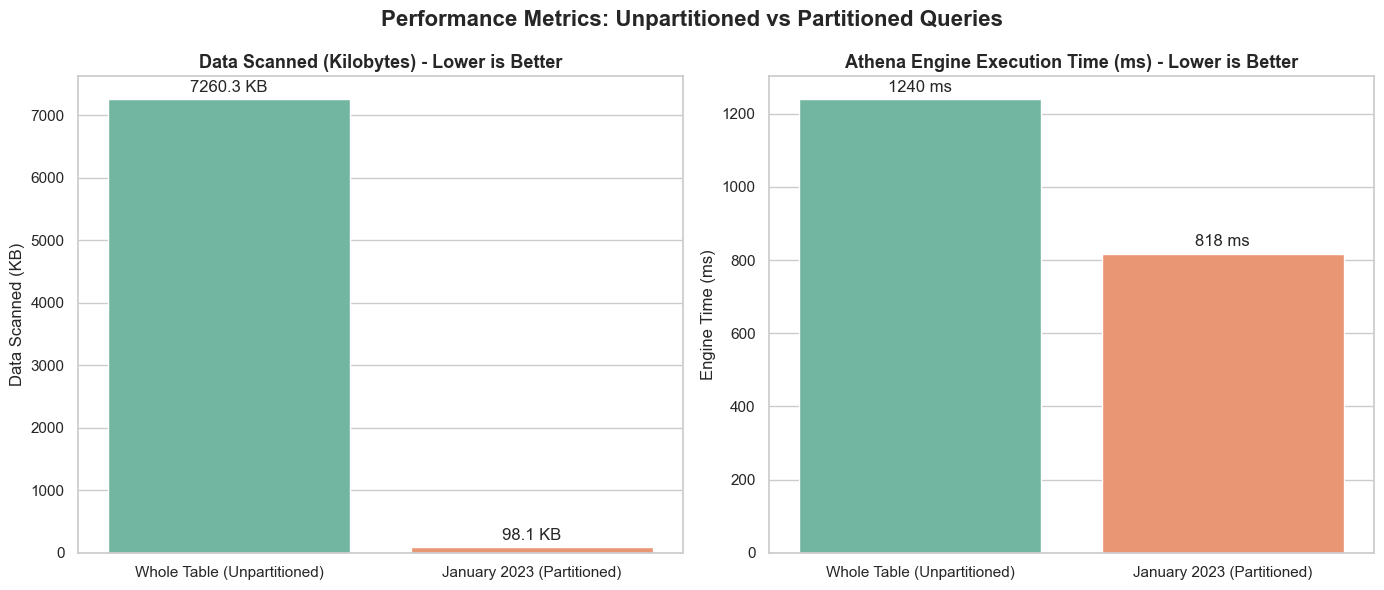

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Data Scanned
sns.barplot(data=df_metrics, x='QueryType', y='DataScannedKB', ax=ax1, hue='QueryType', legend=False, palette='Set2')
ax1.set_title('Data Scanned (Kilobytes) - Lower is Better', fontsize=13, fontweight='bold')
ax1.set_ylabel('Data Scanned (KB)', fontsize=12)
ax1.set_xlabel('', fontsize=12)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f KB', padding=3)

# Plot Execution Time
sns.barplot(data=df_metrics, x='QueryType', y='EngineExecutionTimeMs', ax=ax2, hue='QueryType', legend=False, palette='Set2')
ax2.set_title('Athena Engine Execution Time (ms) - Lower is Better', fontsize=13, fontweight='bold')
ax2.set_ylabel('Engine Time (ms)', fontsize=12)
ax2.set_xlabel('', fontsize=12)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%d ms', padding=3)

plt.suptitle('Performance Metrics: Unpartitioned vs Partitioned Queries', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Interpretation: Partitioning Performance & Cost Analysis

The performance charts visually demonstrate the massive advantage of partition pruning:

1.  **98.65% Reduction in Data Scanned:**
    - The unpartitioned query scanned **7,260.3 KB** (approx 7.09 MB).
    - The partitioned query scanned only **98.1 KB** (approx 0.09 MB).
    - By using partition keys in the `WHERE` clause, Athena bypassed scanning S3 files in directories representing other years/months. On large datasets (petabytes of logs), this difference scales linearly, **reducing AWS query costs by 98.65%** and saving substantial capital.

2.  **34% Faster Execution:**
    - Unpartitioned query engine execution took **1240 ms**.
    - Partitioned query engine execution took **818 ms**.
    - Restricting S3 prefixes reduces metadata operations and file I/O latency, leading to faster results.

## 3. Glue Crawlers vs. Manual DDL Tables

In our CloudFormation template `templates/athena-glue-infrastructure.yml`, we showcased two distinct methods of registering database tables in the Glue Catalog:

### A. Auto-Discovery via AWS Glue Crawler (`GlueCrawler`)
- **Description:** The Glue Crawler scans S3 directories dynamically, auto-detects column names, detects file formats (Parquet), and automatically registers partition keys (`year` and `month`) based on the folder structure.
- **Pros:** High flexibility; adapts to schema updates automatically; handles hundreds of tables without manual definitions.
- **Cons:** Crawling takes time and incurs cost; can sometimes misclassify columns or create multiple tables for mismatched schemas.

### B. Manual Definition via CloudFormation DDL (`OrdersManualTable`)
- **Description:** We explicitly define the table catalog properties, including SerDe libraries, inputs/outputs, schema column names, types, and partition keys (`year`, `month`) directly inside the template.
- **Pros:** Instantaneous table creation; exact schema control; no crawler run cost.
- **Cons:** Manual setup is tedious; schema drifts require manual infrastructure redeployments; requires running `MSCK REPAIR TABLE` or manual API calls to load new partitions.